# To get average honsfield of selected zones from main image

In [6]:
import os
import pydicom
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Polygon

In [7]:
# Load DICOM file
dicom_path = r"./00000005.dcm"
if not os.path.exists(dicom_path):
    print("DICOM file does not exist.")
    exit()

dicom_file = pydicom.dcmread(dicom_path)
image = dicom_file.pixel_array

In [19]:
# Load and threshold all masks
mask_paths = [
    "./New Masks/1 - Total.png",
    "./New Masks/2 - Neck.png",
    "./New Masks/3 - Ward.png",
    "./New Masks/4 - Trochanter.png"
]

masks = {}
for mask_path in mask_paths:
    if not os.path.exists(mask_path):
        print(f"Mask file {mask_path} does not exist. Skipping...")
        continue
    mask = Image.open(mask_path)
    mask_gray = mask.convert('L')
    _, mask_binary = cv2.threshold(np.array(mask_gray), 128, 255, cv2.THRESH_BINARY)
    masks[mask_path.split('/')[-1]] = mask_binary > 0

    # Validate mask dimensions
    if mask_binary.shape != image.shape:
        print(f"Mask dimensions {mask_binary.shape} do not match DICOM image dimensions {image.shape}. Resizing mask...")
        mask_binary = cv2.resize(mask_binary.astype(np.uint8), (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        masks[mask_path.split('/')[-1]] = mask_binary > 0

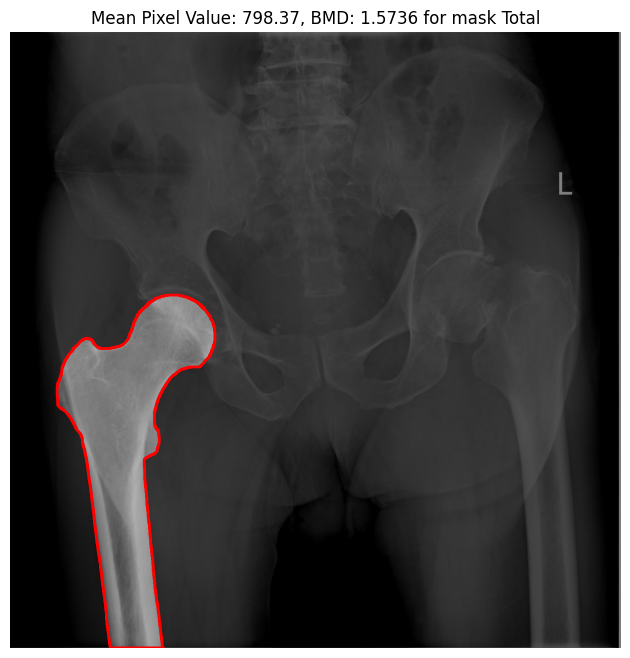

Mean pixel value in the mask Total : 798.37
BMD in the mask Total: 1.5736


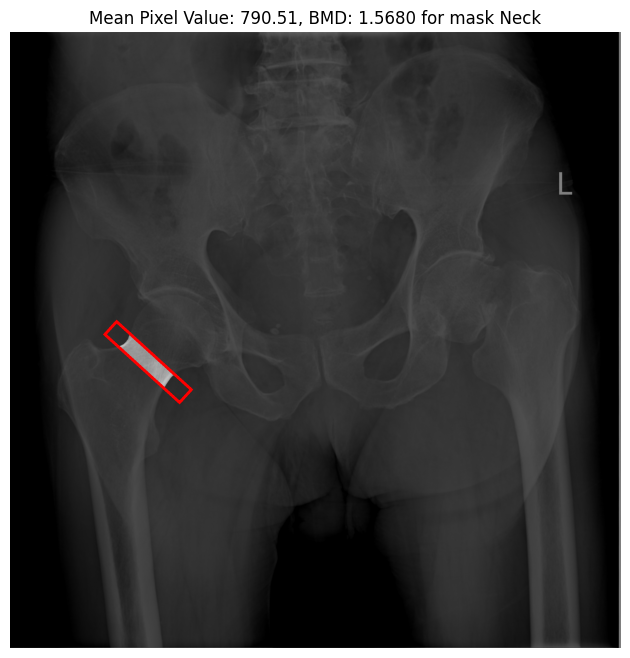

Mean pixel value in the mask Neck : 790.51
BMD in the mask Neck: 1.5680


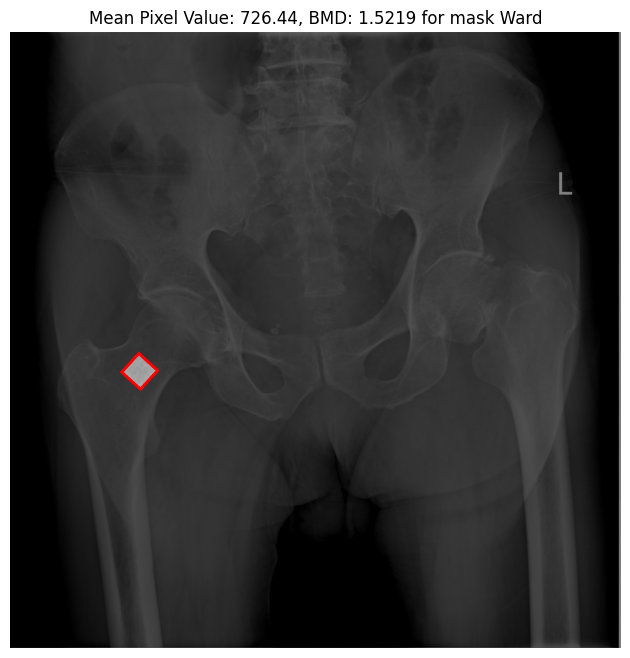

Mean pixel value in the mask Ward : 726.44
BMD in the mask Ward: 1.5219


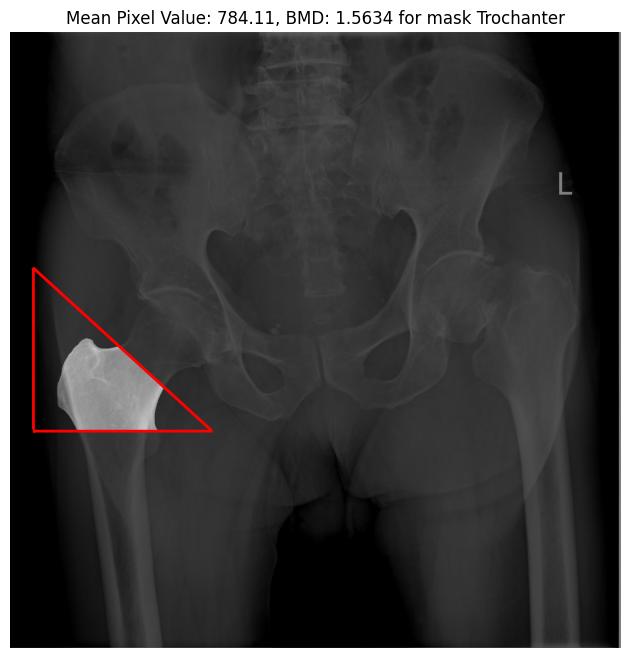

Mean pixel value in the mask Trochanter : 784.11
BMD in the mask Trochanter: 1.5634


In [23]:
# Process each mask
for mask_path in mask_paths:
    mask_name = mask_path.split('/')[-1]
    mask_binary = masks[mask_name]

    if not np.any(mask_binary):
        print(f"Mask {mask_name} is empty. Skipping...")
        continue

    # Find exact boundaries (contour) of the mask
    contours, _ = cv2.findContours(mask_binary.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = contours[0] if contours else np.array([])

    # Calculate mean pixel value
    if mask_name == '1 - Total.png':
        masked_pixels = image[mask_binary]
    else:
        mask1 = masks['1 - Total.png']
        intersection = mask_binary & mask1  # Intersection with mask 1
        masked_pixels = image[intersection]

    if len(masked_pixels) == 0:
        print(f"Mask {mask_name} has no valid pixels after intersection. Skipping...")
        continue

    # Changing mask name for printing stuff:
    mask_name = mask_name.split(".")[0].split("-")[1].strip()
    masked_pixels = (masked_pixels + 1024) / 16 - 1024
    mean_pixel_value = masked_pixels.mean()
    bmd = (7.185 * mean_pixel_value *(10**-4)) + 1

    # Create plots
    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap='gray')
    plt.title(f"Mean Pixel Value: {mean_pixel_value:.2f}, BMD: {bmd:.4f} for mask {mask_name.split(".")[0]}")

    # Draw exact boundary
    if len(contour) > 0:
        plt.gca().add_patch(Polygon(contour[:, 0, :], linewidth=2, edgecolor='red', facecolor='none'))

    # Illustrate the region used for mean calculation
    if mask_name == 'Total':
        mean_region = mask_binary
    else:
        mean_region = mask_binary & masks['1 - Total.png']
    overlay = np.zeros_like(image)
    overlay[mean_region] = image[mean_region]
    plt.imshow(overlay, cmap='gray', alpha=0.5)

    plt.axis('off')
    plt.show()

    print(f"Mean pixel value in the mask {mask_name.split(".")[0]} : {mean_pixel_value:.2f}")
    print(f"BMD in the mask {mask_name.split(".")[0]}: {bmd:.4f}")